
# Importação e leitura dos dados

In [1]:
# 📦 Importação e leitura dos dados
# Carrega o dataset de transações de cartão de crédito e mostra as primeiras linhas.

import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head(200)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,128.0,1.239495,-0.182609,0.155058,-0.928892,-0.746227,-1.235608,-0.061695,-0.125223,0.984938,...,0.146077,0.481119,-0.140019,0.538261,0.710720,-0.621382,0.036867,0.010963,8.80,0
196,130.0,-0.485238,0.658497,1.949967,1.249695,0.426410,0.231513,0.585115,0.029163,-0.520297,...,0.007290,0.328244,-0.232563,0.225572,0.025892,-0.247395,-0.025381,-0.118565,5.97,0
197,130.0,1.353283,-0.694900,0.970826,-0.426559,-1.417263,-0.505710,-0.932069,-0.083957,-0.224208,...,0.284341,0.993434,-0.164893,0.474257,0.623848,-0.006750,0.046026,0.022043,15.93,0
198,131.0,-1.007391,1.261943,1.207203,1.307575,0.153211,0.062291,0.508647,0.079447,-0.395211,...,0.039150,0.411661,-0.080320,0.121235,-0.133000,-0.303177,-0.463913,-0.164157,10.00,0


# Distribuição da variável alvo

In [2]:
# 📊 Distribuição da variável alvo
# Mostra a proporção de fraudes (1) e não fraudes (0).
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


# Feature Engineering

In [3]:
# ⚙️ Feature Engineering
# Cria novas variáveis transformadas e normalizadas.

import numpy as np
df["Amount_log"] = np.log1p(df["Amount"])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

# Split dos dados

In [4]:
# 🔀 Split dos dados + Validação cruzada
# Divide o dataset e aplica validação cruzada estratificada.

from sklearn.model_selection import StratifiedKFold, cross_val_score

X = df.drop("Class", axis=1)
y = df["Class"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)

scores = cross_val_score(log_reg, X, y, cv=skf, scoring="recall")
print("Recall médio (CV):", scores.mean())

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Recall médio (CV): 0.6463409606266748


# Logistic Regression

In [5]:

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Métricas adicionais (ROC, PR Curve)

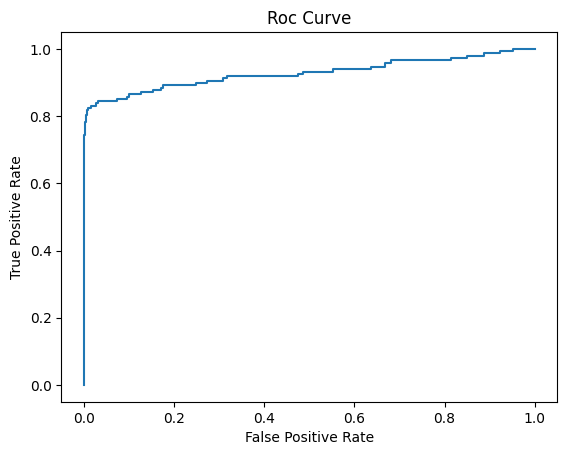

AUC:  0.9272042339543365


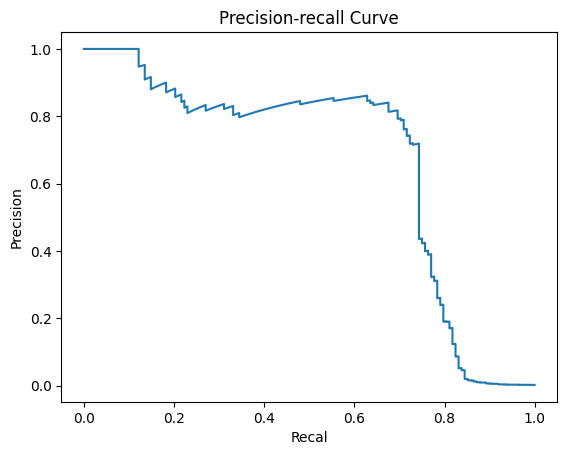

In [6]:
# 🤖 Modelo base - Regressão Logística
# Treina e avalia o modelo inicial.

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

# 📈 Métricas adicionais (ROC e Precision-Recall)
# Avalia o desempenho do modelo com métricas adequadas para dados desbalanceados.
plt.plot(fpr, tpr)
plt.title("Roc Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC: ", roc_auc_score(y_test, y_probs))

from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-recall Curve")
plt.xlabel("Recal")
plt.ylabel("Precision")
plt.show()

# Balanceamento de dados

In [7]:
# Undersampling
# ⚖️ Balanceamento dos dados
# Aplica undersampling e oversampling (SMOTE).

fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)
df_under = pd.concat([fraudes, normais])

In [8]:
# Oversampling
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X,y)

# Random Forest

In [12]:
# 🧩 Ensemble de modelos
# Combina Logistic Regression, Random Forest e XGBoost para maior robustez.

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

log_reg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

xgb = XGBClassifier(scale_pos_weight=10, use_label_encoder=False, eval_metric="logloss")

ensemble = VotingClassifier(
    estimators=[("lr", log_reg), ("rf", rf), ("xgb", xgb)],
    voting="soft"
)

ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)
print(classification_report(y_test, y_pred_ensemble))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [17:00:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.76      0.81       148

    accuracy                           1.00     85443
   macro avg       0.93      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



# Ajuste de threshold

In [ ]:
# 🎯 Ajuste de threshold
# Em problemas de fraude, é mais importante detectar o maior número possível de fraudes (recall).
# Aqui ajustamos o threshold para 0.25, tornando o modelo mais sensível.

y_probs = ensemble.predict_proba(X_test)[:,1]
threshold = 0.25
y_pred_custom = (y_probs > threshold).astype(int)

print("Relatório com threshold ajustado:")
print(classification_report(y_test, y_pred_custom))

# XGBoost

In [ ]:
# ⚡ Modelo XGBoost isolado
# Treinamos o XGBoost separadamente para comparar com o ensemble.
# O parâmetro scale_pos_weight ajuda a lidar com o desbalanceamento.

from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

# Importância das variáveis

In [ ]:
# 🔍 Importância das variáveis
# Mostra quais features mais influenciam o modelo XGBoost.
# Isso ajuda a entender o que o modelo está usando para detectar fraudes.

importancias = xgb.feature_importances_
plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

# GridSearch

In [16]:
# 🧩 Ajuste de hiperparâmetros com GridSearch
# Testa diferentes combinações de parâmetros para melhorar recall.
# Aqui variamos max_depth e n_estimators

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)
print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 5, 'n_estimators': 100}


# SHAP

In [ ]:
# 🧠 Explicabilidade com SHAP
# O SHAP mostra o impacto das variáveis nas previsões.
# Isso ajuda analistas a entender por que uma transação foi classificada como fraude.

import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])
shap.plots.bar(shap_values)